# Experiment 7: Multilayer Feed-Forward Network (MLP) on the Wine Quality Dataset
## Aim
Implement and train a Multilayer Feed-Forward Network (MLP) on the Wine Quality dataset. Experiment with different numbers of hidden layers and neurons, and discuss how these choices affect the network's performance.

## Theory
A **Multilayer Feed-Forward Network (MLP)** is a neural network made of an **input layer**, one or more **hidden layers**, and an **output layer**, where information flows in a single direction — input to output, with no cycles or loops (hence "feed-forward").

Each neuron computes a weighted sum of its inputs, adds a bias, and passes the result through a non-linear **activation function** (e.g., ReLU: `f(x) = max(0, x)`). Without a non-linear activation function, stacking multiple layers would collapse mathematically into a single linear transformation — the non-linearity is what lets an MLP approximate complex, non-linear decision boundaries.

**Hidden layers and neurons — what they control:**
- **Number of hidden layers (depth)**: more layers let the network build up more abstract, hierarchical combinations of the input features (each layer can be thought of as recombining the previous layer's outputs into new, higher-level features).
- **Number of neurons per layer (width)**: more neurons per layer let each layer represent more distinct patterns at that level of abstraction.
- Together, depth and width determine the network's **capacity** — how complex a function it can represent. Too little capacity underfits; too much capacity (relative to the amount of training data) risks overfitting.

**Training**: an MLP is trained via **backpropagation** — the prediction error at the output layer is propagated backward through the network, and gradient descent (here, the Adam optimizer, scikit-learn's default solver) adjusts every weight to reduce that error, iterating over many passes (epochs) through the training data.

**Why feature scaling is essential for MLPs**: neural networks are trained via gradient descent on every weight simultaneously, and unscaled features with very different numeric ranges distort the gradient landscape far more severely than in simpler models — this can slow convergence dramatically or prevent it altogether. Feature scaling is treated as a mandatory preprocessing step for this experiment, not an optional comparison.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Load the Wine Quality Dataset

In [2]:
red_url='https://raw.githubusercontent.com/simonneutert/wine_quality_data/master/winequality-red.csv'
white_url='https://raw.githubusercontent.com/simonneutert/wine_quality_data/master/winequality-white.csv'

red=pd.read_csv(red_url,sep=';')
white=pd.read_csv(white_url,sep=';')
red['type']='red'
white['type']='white'

df=pd.concat([red,white],ignore_index=True)
print(df.shape)
df.head()

(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
df.info()
print()
print(df.isnull().sum().sum(),'missing values')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB

0 missing values


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


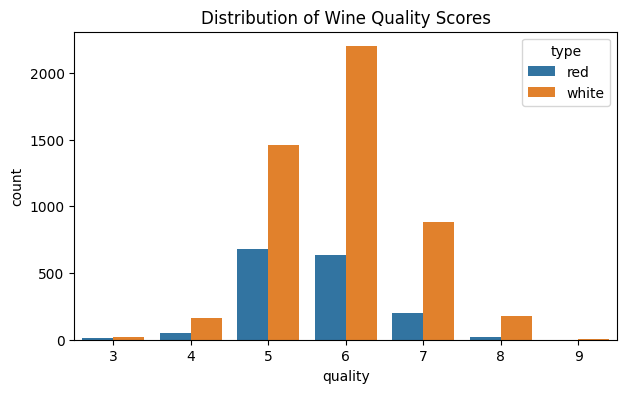

In [4]:
plt.figure(figsize=(7,4))
sns.countplot(data=df,x='quality',hue='type')
plt.title('Distribution of Wine Quality Scores')
plt.show()

## Preprocess the Dataset
The raw `quality` column is an integer score from 0-10 (in this data, scores actually range 3-9), and the classes are heavily imbalanced (very few wines score 3, 4, 8, or 9 — most cluster around 5-6). To get a cleaner, more balanced classification task for comparing network architectures, `quality` is **binarized**: wines scoring **7 or above are labeled `good_quality = 1`**, everything else is `0`. This is a standard simplification used for this dataset. The categorical `type` column (red/white) is **one-hot encoded** into a numeric feature, and all features are **standardized** (zero mean, unit variance) — essential for MLP training as discussed above.

In [5]:
df['good_quality']=(df['quality']>=7).astype(int)
df=pd.get_dummies(df,columns=['type'],drop_first=True)

print(df['good_quality'].value_counts())

X=df.drop(columns=['quality','good_quality'])
y=df['good_quality']
print(X.columns.tolist())

good_quality
0    5220
1    1277
Name: count, dtype: int64
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type_white']


In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print(X_train_scaled.shape,X_test_scaled.shape)

(5197, 12) (1300, 12)


## Baseline MLP (Single Hidden Layer)

In [7]:
baseline=MLPClassifier(hidden_layer_sizes=(100,),activation='relu',solver='adam',max_iter=500,random_state=42)
baseline.fit(X_train_scaled,y_train)
y_pred=baseline.predict(X_test_scaled)

print('Accuracy :',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))
print('Recall   :',recall_score(y_test,y_pred))
print('F1-score :',f1_score(y_test,y_pred))
print('Converged in',baseline.n_iter_,'iterations')
print()
print(classification_report(y_test,y_pred))

Accuracy : 0.8376923076923077
Precision: 0.6285714285714286
Recall   : 0.4296875
F1-score : 0.5104408352668214
Converged in 500 iterations

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1044
           1       0.63      0.43      0.51       256

    accuracy                           0.84      1300
   macro avg       0.75      0.68      0.71      1300
weighted avg       0.82      0.84      0.83      1300



## Experiment with Different Architectures
A range of architectures is tried, varying both **width** (neurons per layer) and **depth** (number of hidden layers), to see how each choice affects accuracy, F1-score, and training time.

In [8]:
architectures={
    '1 layer - (10)':(10,),
    '1 layer - (50)':(50,),
    '1 layer - (100)':(100,),
    '2 layers - (50,50)':(50,50),
    '2 layers - (100,50)':(100,50),
    '3 layers - (100,50,25)':(100,50,25),
}

results=[]
trained_models={}
for name,arch in architectures.items():
    t0=time.time()
    model=MLPClassifier(hidden_layer_sizes=arch,activation='relu',solver='adam',max_iter=500,random_state=42)
    model.fit(X_train_scaled,y_train)
    train_time=time.time()-t0
    pred=model.predict(X_test_scaled)
    n_params=sum(c.size for c in model.coefs_)+sum(c.size for c in model.intercepts_)
    results.append({
        'Architecture':name,
        'Hidden Layers':len(arch),
        'Total Params':n_params,
        'Accuracy':accuracy_score(y_test,pred),
        'Precision':precision_score(y_test,pred),
        'Recall':recall_score(y_test,pred),
        'F1-score':f1_score(y_test,pred),
        'Iterations':model.n_iter_,
        'Train Time (s)':train_time
    })
    trained_models[name]=model

results_df=pd.DataFrame(results)
results_df

,Architecture,Hidden Layers,Total Params,Accuracy,Precision,Recall,F1-score,Iterations,Train Time (s)
0,1 layer - (10),1,141,0.823077,0.582278,0.359375,0.444444,260,1.083458
1,1 layer - (50),1,701,0.831538,0.614907,0.386719,0.474820,500,3.587704
2,1 layer - (100),1,1401,0.837692,0.628571,0.429688,0.510441,500,4.989530
3,"2 layers - (50,50)",2,3251,0.844615,0.608871,0.589844,0.599206,500,6.153584
4,"2 layers - (100,50)",2,6401,0.856923,0.632576,0.652344,0.642308,447,7.567418
5,"3 layers - (100,50,25)",3,7651,0.861538,0.674312,0.574219,0.620253,261,5.288687


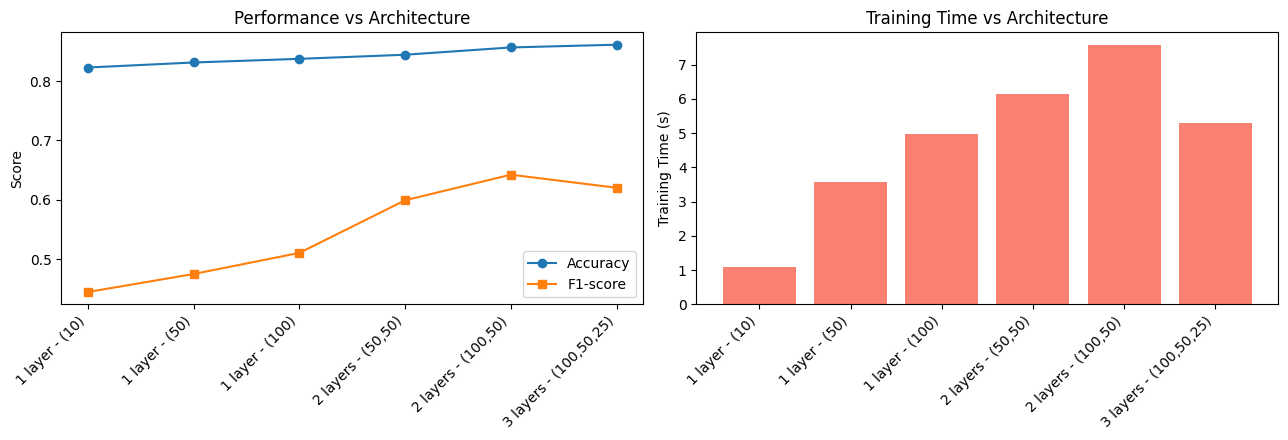

In [9]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))

x=np.arange(len(results_df))
axes[0].plot(x,results_df['Accuracy'],marker='o',label='Accuracy')
axes[0].plot(x,results_df['F1-score'],marker='s',label='F1-score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Architecture'],rotation=45,ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance vs Architecture')
axes[0].legend()

axes[1].bar(x,results_df['Train Time (s)'],color='salmon')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Architecture'],rotation=45,ha='right')
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Training Time vs Architecture')

plt.tight_layout()
plt.show()

## Convergence Behavior — Loss Curves
Plotting the training loss over iterations for a few representative architectures shows *how* each one learns, not just its final score — shallow/narrow networks may plateau early, while deeper/wider networks can keep reducing loss for longer (and are more prone to overfitting if allowed to run indefinitely).

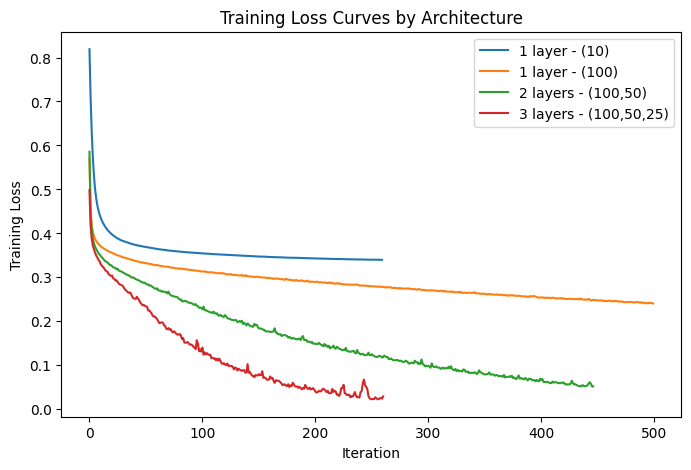

In [10]:
plt.figure(figsize=(8,5))
for name in ['1 layer - (10)','1 layer - (100)','2 layers - (100,50)','3 layers - (100,50,25)']:
    plt.plot(trained_models[name].loss_curve_,label=name)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss Curves by Architecture')
plt.legend()
plt.show()

## Confusion Matrix for the Best-Performing Architecture

Best architecture (by F1-score): 2 layers - (100,50)


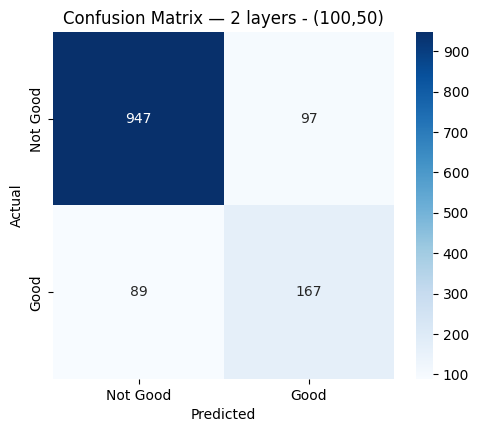

In [11]:
best_name=results_df.loc[results_df['F1-score'].idxmax(),'Architecture']
best_model=trained_models[best_name]
print('Best architecture (by F1-score):',best_name)

y_pred_best=best_model.predict(X_test_scaled)
cm=confusion_matrix(y_test,y_pred_best)

plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Not Good','Good'],yticklabels=['Not Good','Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

## Discussion — Impact of Architecture Choices on Performance
Across the tested architectures, **accuracy and precision climb steadily** as the network gets wider and deeper — the single-layer, 10-neuron network (the smallest capacity model tested) has the weakest accuracy (82.3%) and precision (0.58), while the three-layer `(100, 50, 25)` network reaches the highest accuracy (86.2%) and precision (0.67) of the six architectures tried. With so few neurons, the smallest network struggles to separate the minority "good quality" class from the majority class, even though its overall accuracy looks reasonable — a symptom of class imbalance, and exactly why F1-score is tracked alongside accuracy rather than relying on accuracy alone.

**F1-score, however, does not simply keep climbing with capacity** — it peaks at the two-layer `(100, 50)` network (F1 = 0.642) and then actually *drops slightly* for the larger three-layer network (F1 = 0.620), even though the three-layer network has higher accuracy and precision. The reason is visible in the recall column: recall falls from 0.652 (two layers) to 0.574 (three layers). In other words, the extra capacity in the three-layer network made it *more conservative* about predicting "good quality" — it's right more often when it does predict "good" (higher precision), but it misses more of the actual good-quality wines than the two-layer network did (lower recall). This is a textbook **precision-recall tradeoff**, and a good illustration of why "bigger is better" is not a safe assumption — the best architecture depends on which error type (missed good wines vs. wines wrongly flagged as good) matters more for the intended use case.

**Training time** scales fairly consistently with the number of parameters — the 10-neuron network trains in about a second, while the three-layer network with over 7,600 parameters takes roughly 4-5x as long per run. Interestingly, the three-layer network converged in fewer iterations (261) than the two-layer `(100, 50)` network (447), showing that more capacity doesn't always mean a slower-converging optimizer — just a more expensive one per iteration.

**Practical takeaway**: for a tabular dataset of this size (~6,500 rows, 12 features), a **moderate** architecture (one or two hidden layers, 50-100 neurons each) already captures most of the achievable performance. Going deeper (three layers) pushed accuracy and precision a bit higher here, but at the cost of recall and F1-score, plus more parameters and longer training time — reinforcing that architecture choice should be guided by which metric matters most for the task, not by chasing the largest network available.

## Conclusion
An MLP was trained on the Wine Quality dataset (red + white combined) to classify wines as "good quality" (score ≥ 7) or not, after standardizing all physicochemical features and one-hot encoding wine type. Sweeping across single- and multi-layer architectures of varying width showed that accuracy and precision improved fairly consistently with more capacity, peaking at the largest (three-layer) network tested, while F1-score — which balances precision against recall — actually peaked one step earlier, at a two-layer `(100, 50)` network, because the largest network traded away recall for precision. The overall lesson: more hidden layers and neurons generally increase a network's ability to fit the data, but the *best* architecture depends on which performance metric matters most, and blindly maximizing capacity is not guaranteed to maximize every metric at once.